In [2]:
import numpy as np
import matplotlib.pyplot as plt
import esigmapy

In [3]:
import os
x=os.environ.get("ModePNOrder")
print('Poof!' if x is None else int(x))

y=os.environ.get("LAL_DATA_PATH")
print('Poof!' if y is None else y)

Poof!
:/home/samanwaya/nrsur7dq4


### Inspiral ESIGMA modes

In [19]:
from esigmapy.python_codes import generator_python as gp

m1 = 20.0  # masses (in solar masses)
m2 = 30.0
spin1z = 0.5  # dimensionless spins
spin2z = -0.3
eccentricity = 0.15  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**10  # time grid-spacing (in s)

print('================ Python ================')
inspiral_modes_py = gp.get_inspiral_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

print('================= C =================')
inspiral_modes_c = esigmapy.get_inspiral_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)


================ Python ================
Radiation PN order = 8
Orbital evolution took: 3.262218417999975 seconds
Mode PN order = 8
Mode PN order = 8
Modes generation took: 0.3844245680011227 seconds
================= C =================
Orbital evolution took: 0.05307760899813729 seconds
Modes generation took: 0.011499872998683713 seconds


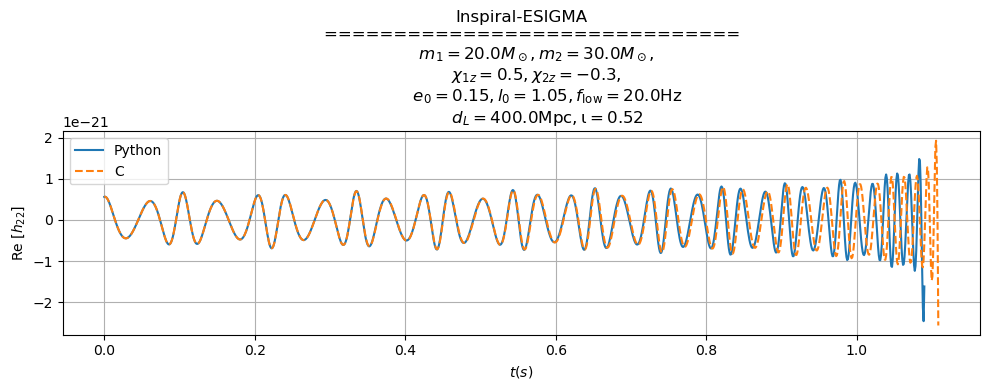

In [21]:
hp22_py_real_inspiral = inspiral_modes_py[(2, 2)].real()
hp22_c_real_inspiral = inspiral_modes_c[(2, 2)].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""Inspiral-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

hp22_py_real_inspiral.start_time=0
hp22_c_real_inspiral.start_time=0

plt.plot(hp22_py_real_inspiral.sample_times,hp22_py_real_inspiral,label='Python')
plt.plot(hp22_c_real_inspiral.sample_times,hp22_c_real_inspiral,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
# plt.xlim(0.2,0.3)
# plt.ylim(-1e-21,1e-21)
plt.tight_layout()

dict_keys([(2, 2), (2, -2)])


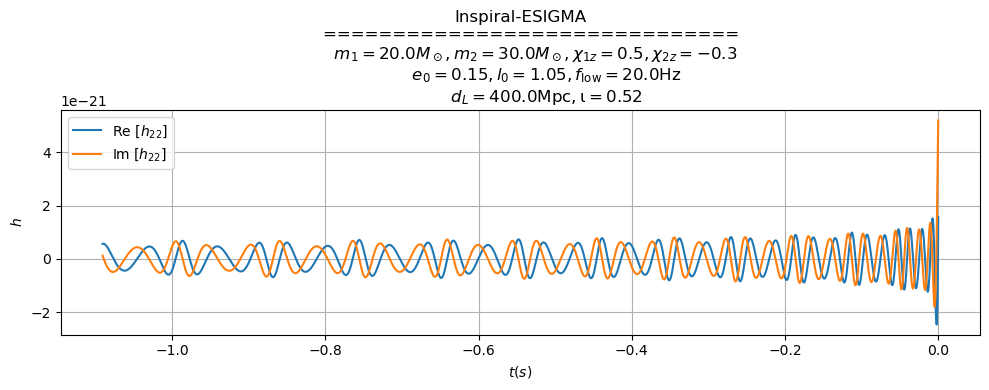

In [ ]:
print(inspiral_modes_py.keys())
hp22_inspiral = inspiral_modes_py[(2, 2)].real()
hc22_inspiral = inspiral_modes_py[(2, 2)].imag()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""Inspiral-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_inspiral.sample_times,hp22_inspiral,label=r"Re [$h_{22}$]")
plt.plot(hc22_inspiral.sample_times,hc22_inspiral,label=r"Im [$h_{22}$]")

plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.grid()
plt.tight_layout()

### IMR ESIGMA modes

In [ ]:
from esigmapy.python_codes import generator_python as gp

m1 = 20.0  # masses (in solar masses)
m2 = 30.0
spin1z = 0.5  # dimensionless spins
spin2z = -0.3
eccentricity = 0.15  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

print('================ Python ================')
imr_modes_py = gp.get_imr_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

print('================= C =================')
imr_modes_c = esigmapy.get_imr_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)


================ Python ================
Radiation PN order = 8
Orbital evolution took: 8.60927068700039 seconds
Mode PN order = 8
Mode PN order = 8
Modes generation took: 1.4204796830017585 seconds
Generating MR waveform from 49.62645847549604Hz...
Hybridizing the following modes: [(2, 2), (2, -2)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(2, -2), (2, 2)] modes
INSPIRAL mode (2, 2) goes from 15.51002742012073Hz to 133.6547676158098Hz
MERGER mode (2, 2) goes from 49.67733142367634Hz to 351.6339524069211Hz
INSPIRAL mode (2, -2) goes from -133.6547676158098Hz to -15.51002742012073Hz
MERGER mode (2, -2) goes from -352.64823272619185Hz to -49.67650156836734Hz
blended.
================= C =================
Orbital evolution took: 0.012976661000720924 seconds
Modes generation took: 0.045316491999983555 seconds
Generating MR waveform from 49.79651161822471Hz...
Hybridizing the following modes: [(2, 2), (2, -2)]
By aligning (2, 2) mode
..and inheriting t

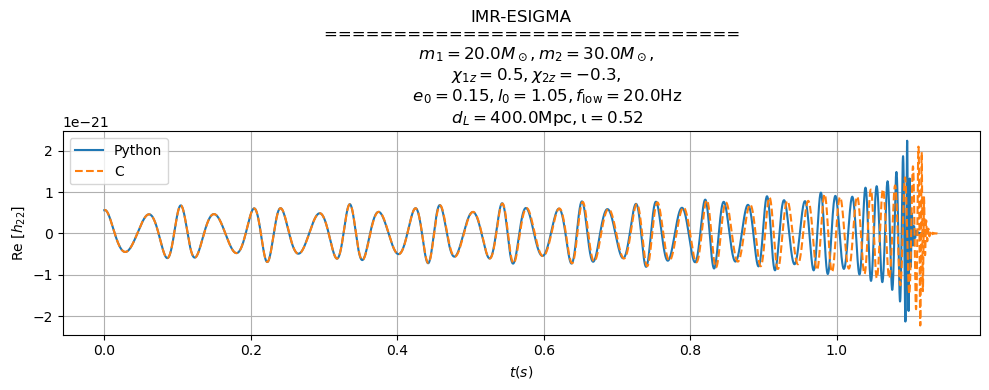

In [ ]:
hp22_py_real_imr = imr_modes_py[(2, 2)].real()
hp22_c_real_imr = imr_modes_c[(2, 2)].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

hp22_py_real_imr.start_time=0
hp22_c_real_imr.start_time=0

plt.plot(hp22_py_real_imr.sample_times,hp22_py_real_imr,label='Python')
plt.plot(hp22_c_real_imr.sample_times,hp22_c_real_imr,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
plt.tight_layout()

dict_keys([(2, 2), (2, -2)])


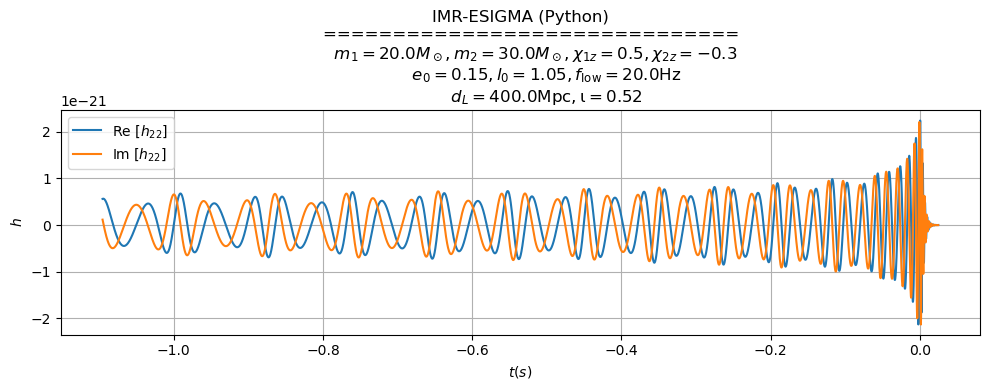

In [ ]:
print(imr_modes_py.keys())
hp22_imr = imr_modes_py[(2, 2)].real()
hc22_imr = imr_modes_py[(2, 2)].imag()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA (Python)
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_imr.sample_times,hp22_imr,label=r"Re [$h_{22}$]")
plt.plot(hc22_imr.sample_times,hc22_imr,label=r"Im [$h_{22}$]")

plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.grid()
plt.tight_layout()